In [1]:
class AddLayer:
  def __init__(self):
    pass

  def foward(self, x,y):
    out = x + y
    return out

  def backward(self, dout):
    dx = dout * 1
    dy = dout * 1

    return dx, dy

In [2]:
class MulLayer:
  def __init__(self): # initialize x and y
    self.x = None
    self.y = None

  def foward(self, x, y):
    self.x = x
    self.y = y
    out = x * y

    return out

  def backward(self, dout):
    dx = dout * self.y # 곱셈 노드에서 역전파는 x 와 y를 스위칭 하여 이전 입력 신호에 곱하여 다음 노드로 전달 한다.

    dy = dout * self.x

    return dx, dy

In [3]:
from numpy import exp
class SigLayer:
  def __init__(self):
    self.out = None

  def foward(self, x):
    out = 1 / (1 + exp(-x))
    self.out = out
    return out

  def backward(self, dout):
    dx = dout * self.out * (1 - self.out)
    return dx

In [4]:
class ReluLayer:
  def __inut__(self):
    self.mask = None

  def foward(self, x):
    self.mask = (x >= 0)
    if self.mask: out = x
    else: out = 0.1 * x
    return out

  def backward(self, dout):
    if self.mask: dx = dout
    else: dx = dout * 0.1
    return dx

In [5]:
class StepLayer:
  def __init__(self):
    self.out = None

  def foward(self, x):
    self.out = 1 if x >= 0.5 else 0
    return self.out

In [6]:
import numpy

왜 w1하고 w2, w3하고 w4가 똑같지?
왜 dw1하고 dw2, dw3하고 dw4가 똑같지?
똑같으면 안되는데 달라야 가중치가 달라지는데
왜 0, 1, 1일 때 dw1, dw2가 0이지? dw1하고 dw3하고 0이어야하는데?
잘못 짬
아니 왜 은닉층의 활성화 함수를 렐루로 써야하지?
시그모이드는 왜 안되는데?
변화량이 너무 적어서
근데 relu를 썼는데도 1, 1일 때랑 0, 1일 때 차이가 너무 미미한데

In [7]:
import random
dataset = [[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 0]]
x1 = None
b1 = random.uniform(-2, 2)
w1 = random.uniform(-2, 2)
w3 = random.uniform(-2, 2)
mul1 = MulLayer()
mul2 = MulLayer()
add5 = AddLayer()

x2 = None
b2 = random.uniform(-2, 2)
w2 = random.uniform(-2, 2)
w4 = random.uniform(-2, 2)
mul3 = MulLayer()
mul4 = MulLayer()
add6 = AddLayer()

#u1 = x1*w1 + x1*w3 + b1
rel7 = ReluLayer()
#h1 = sig(u1)
w5 = random.uniform(-2, 2)
mul9 = MulLayer()
#u2 = x2*w2 + x2*w4 + b2
rel8 = ReluLayer()
#h2 = sig(u2)
w6 = random.uniform(-2, 2)
mul10 = MulLayer()

b3 = random.uniform(-2, 2)
add11 = AddLayer()
#o1 = h1*w5 + h2*w6 + b3
sig12 = SigLayer()
#y = sig(o1)
step13 = StepLayer()

w1, w2, w3, w4, w5, w6 = [0.24184754, -1.51006156, -0.52303691, 0.9798914, 0.9113579, 1.28466551]
b1, b2, b3 =  [ 0.09211053, -0.42240002 ,-0.08082465]
print(w1, w2, w3, w4, w5, w6)
print(b1, b2, b3)
lr = 1
for epoch in range(1000):
  idx = numpy.random.permutation(len(dataset))
  for i in idx:
    x1 = dataset[i][0]
    x2 = dataset[i][1]
    label = dataset[i][2]

    #u1 = add5.foward(mul1.foward(x1, w1), mul2.foward(x1, w3)) + b1
    #u2 = add6.foward(mul3.foward(x2, w2), mul4.foward(x2, w4)) + b2
    #u1 = add5.foward(mul1.foward(x1, w1), mul3.foward(x1, w3)) + b1
    #u2 = add6.foward(mul2.foward(x2, w2), mul4.foward(x2, w4)) + b2
    u1 = add5.foward(mul1.foward(x1, w1), mul2.foward(x2, w2)) + b1
    u2 = add6.foward(mul3.foward(x1, w3), mul4.foward(x2, w4)) + b2
    h1 = rel7.foward(u1)
    h2 = rel8.foward(u2)
    o1 = add11.foward(mul9.foward(h1, w5), mul10.foward(h2, w6)) + b3
    y = sig12.foward(o1)
    result = step13.foward(y)
    loss = (label - result)**2

    # loss y로 미분한 값(dloss/dy)
    dloss = -(label - y)
    print(epoch, [x1, x2], o1, y, result, loss, dloss)
    #print("rel1, rel2: ", rel7.mask, rel8.mask)

    dout = sig12.backward(dloss) # dout = dloss/dy * dy/do1
    #print("제1 dout: ",dout)
    db3 = lr * dout
    b3 -= lr * dout
    dout1, dout2 = add11.backward(dout) # dout1 = dout, dout2 = dout
    dout2, dw6 = mul10.backward(dout2) # dout2 = dloss/dy * dy/do1 * do1/dh2, dw6 = dloss/dy * dy/do1 * do1/dw6
    dout1, dw5 = mul9.backward(dout1) # dout1 = dloss/dy * dy/do1 * do1/dh1, dw5 = dloss/dy * dy/do1 * do1/dw5
    ## b2 -= dout2
    ## b1 -= dout1
    #print("dout2: ", dout2)
    #print("dout2곱: ",mul10.x)
    #print("dout2w곱: ",mul10.y)
    #print("dout1: ", dout1)
    #print("dout1곱: ", mul9.x)
    #print("dout1w곱: ", mul9.y)
    w6 -= lr * dw6
    w5 -= lr * dw5
    dout2 = rel8.backward(dout2) # dout2 = dloss/dy * dy/do1 * do1/dh2 * dh2/du2
    dout1 = rel7.backward(dout1) # dout1 = dloss/dy * dy/do1 * do1/dh1 * dh1/du1
    #print("rel(dout1):", dout1)
    #print("rel(dout2): ", dout2)
    db2 = lr * dout2
    b2 -= lr * dout2
    b1 -= lr * dout1
    db1 = lr* dout1
    dw4 = mul4.backward(add6.backward(dout2)[1])[1] # dloss/dy * dy/do1 * do1/dh2 * dh2/du2 * du2/dw4
    # add6.backward(dout2)[0~1] = dout2
    dw3 = mul3.backward(add6.backward(dout2)[0])[1] # dloss/dy * dy/do1 * do1/dh2 * dh2/du2 * du2/dw3
    dw2 = mul2.backward(add5.backward(dout1)[1])[1] # dloss/dy * dy/do1 * do1/dh1 * dh1/du1 * du1/dw2
    #print("dw2: ", mul2.x)
    #print("dw2 dout: ", mul2.y)
    #print("dout: ", dout1)
    # add5.backward(dout1)[0~1] = dout1
    dw1 = mul1.backward(add5.backward(dout1)[0])[1] # dloss/dy * dy/do1 * do1/dh1 * dh1/du1 * du1/dw1
    #print("dout2-2: ", mul4.backward(dout2)[0])
    #print("dout2-1: ", mul3.backward(dout2)[0])
    #print("dout1-2: ", mul2.backward(dout1)[0])
    #print("dout1-2: ", mul1.backward(dout1)[0])
    w4 -= lr * dw4
    w3 -= lr * dw3
    w2 -= lr * dw2
    w1 -= lr * dw1
    #print("dw, db: ", [dw1, dw2, dw3, dw4, dw5, dw6], [b1, b2,b3])
    #if sum(predict([[0, 0], [0, 1], [1, 0], [1, 1]], w1, w2, w3, w4, w5, w6, b1, b2, b3) - np.array([0, 1, 1, 0])) == 0:
      #print([w1, w2, w3, w4, w5, w6], [b1, b2, b3])
      #break
    #print(h1, h2)
  print("w: ", w1, w2, w3, w4, w5, w6)
    #print("dw: ", dw1, dw2, dw3, dw4, dw5, dw6)
  print("b: ", b1, b2, b3)
    #print("db: ", db1, db2, db3)
    #print(u1, u2, h1, h2)
    #print(predict(dataset, w1, w2, w3, w4, w5, w6, b1, b2, b3), label)

0.24184754 -1.51006156 -0.52303691 0.9798914 0.9113579 1.28466551
0.09211053 -0.42240002 -0.08082465
0 [0, 0] -0.05114326452304401 0.48721697005789927 0 0 0.48721697005789927
0 [0, 1] 0.35871567525735387 0.5887294997402885 1 0 -0.41127050025971146
0 [1, 0] -0.009566023291476683 0.4976085124139499 0 1 -0.5023914875860501
0 [1, 1] 0.3395289729467189 0.5840761002972074 1 1 0.5840761002972074
w:  0.3400196224237474 -1.5140675249134279 -0.6953432901045857 0.919146646275827 0.928911053906463 1.2893996171102535
b:  0.0883115374973125 -0.4819053029143927 -0.11926486957740991
1 [0, 0] -0.09936815751480309 0.47517838137969726 0 0 0.47517838137969726
1 [1, 1] -0.38300168745649765 0.40540313103480613 0 0 0.40540313103480613
1 [0, 1] 0.03475214154584727 0.5086871611054765 1 0 -0.4913128388945235
1 [1, 0] -0.07122509408543098 0.4822012502847738 0 1 -0.5177987497152262
w:  0.4488303384488577 -1.511621661000026 -0.6905913538886392 1.0658465417234315 0.9513541800582284 1.3328021814527204
b:  0.09846578

In [8]:

import numpy as np
import matplotlib.pyplot as plt
def predict(arr):
  score = np.array([])
  for index in range(len(arr)):
    arr.sort()
    x1 = arr[index][0]
    x2 = arr[index][1]
    a = (x1*w1 + x2*w2+ b1)
    b = (x1*w3 + x2*w4 + b2)
    rel0 = ReluLayer()
    aa, bb = rel0.foward(a), rel0.foward(b)
    y = (w5*aa + w6*bb + b3)
    res = 1/(1+exp(-y))
    if res >= 0.5:
      score = np.append(score, 1)
    else:
      score = np.append(score, 0)
  return score

왜 이렇게 차이가 없냐면 w5하고 w6가 아작나서(거의 0이라서)
왜 아작났지?
w1, w2, w3, w4들은 입력값이 0일 때 안바뀌는데
u1, u2들은 0이 안돼서 자꾸 미세하게 조정됨
u1, u2에도 스텝 함수를 넣어야겠는데

하.. 그냥 u1, u2 문제였네 이걸 이렇게 오래 할 게 아니었네..
시그모이드: 0~1
크로스 엔트로피: a, b, a+b=1
소프트 맥스: a..z, 시그마a..z=1

[[-5.00000000e-01 -5.00000000e-01]
 [-4.00000000e-01 -5.00000000e-01]
 [-3.00000000e-01 -5.00000000e-01]
 [-2.00000000e-01 -5.00000000e-01]
 [-1.00000000e-01 -5.00000000e-01]
 [-1.11022302e-16 -5.00000000e-01]
 [ 1.00000000e-01 -5.00000000e-01]
 [ 2.00000000e-01 -5.00000000e-01]
 [ 3.00000000e-01 -5.00000000e-01]
 [ 4.00000000e-01 -5.00000000e-01]
 [ 5.00000000e-01 -5.00000000e-01]
 [ 6.00000000e-01 -5.00000000e-01]
 [ 7.00000000e-01 -5.00000000e-01]
 [ 8.00000000e-01 -5.00000000e-01]
 [ 9.00000000e-01 -5.00000000e-01]
 [ 1.00000000e+00 -5.00000000e-01]
 [ 1.10000000e+00 -5.00000000e-01]
 [ 1.20000000e+00 -5.00000000e-01]
 [ 1.30000000e+00 -5.00000000e-01]
 [ 1.40000000e+00 -5.00000000e-01]
 [ 1.50000000e+00 -5.00000000e-01]
 [-5.00000000e-01 -4.00000000e-01]
 [-4.00000000e-01 -4.00000000e-01]
 [-3.00000000e-01 -4.00000000e-01]
 [-2.00000000e-01 -4.00000000e-01]
 [-1.00000000e-01 -4.00000000e-01]
 [-1.11022302e-16 -4.00000000e-01]
 [ 1.00000000e-01 -4.00000000e-01]
 [ 2.00000000e-01 -4

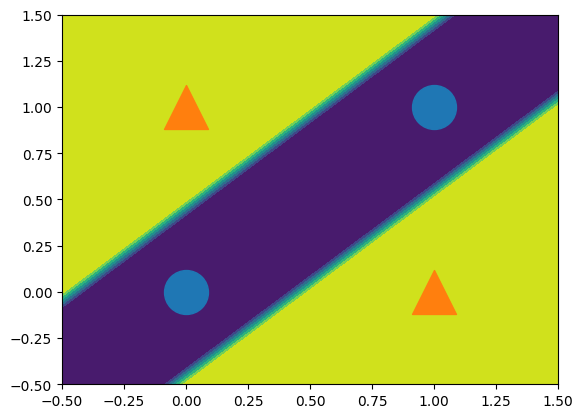

In [9]:
# 경계 영역 플롯
h = 0.1
x_min, x_max = -0.5, 1.51
y_min, y_max = -0.5, 1.51
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X = np.c_[xx.ravel(), yy.ravel()]
print(X)
score = predict(X)
Z = score.reshape(xx.shape)
plt.contourf(xx, yy, Z)
plt.axis('on')
# 데이터점 플롯
x = np.array([[0, 0], [1, 1], [0, 1], [1, 0]])
t = np.array([0, 1])
N = 2
CLS_NUM = 2
markers = ['o', '^']
for i in range(CLS_NUM):
    plt.scatter(x[i*N:(i+1)*N, 0], x[i*N:(i+1)*N, 1], s=1000, marker=markers[i])
plt.show()